In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, classification_report

In [22]:
import os
print("Current working directory:", os.getcwd())

Current working directory: c:\Users\ohril\Projects\exoplanet-transit-classifier


In [23]:
import os

test_path = "test_write.txt"

try:
    with open(test_path, "w") as f:
        f.write("test")
    print("Folder is writable")
    os.remove(test_path)
except PermissionError:
    print("Folder is NOT writable")

Folder is writable


In [24]:
import os
print("Working directory:", os.getcwd())
print("\nAll files with exact names:")
for f in os.listdir("."):
    print(repr(f))

Working directory: c:\Users\ohril\Projects\exoplanet-transit-classifier

All files with exact names:
'koi_clean.csv'
'koi_cumulative.csv'
'transit_classifier.ipynb'


In [25]:
with open("koi_cumulative.csv", "r") as f:
    for i in range(100):
        line = f.readline()
        if "koi_disposition" in line or "kepoi_name" in line:
            print(f"Header found at line {i+1}")
            print(line[:200])
            break
        if i < 5:
            print(f"Line {i+1}: {line[:100]}")

Line 1: # This file was produced by the NASA Exoplanet Archive  http://exoplanetarchive.ipac.caltech.edu

Line 2: # Fri Sep 18 16:23:38 2026

Line 3: #

Line 4: # COLUMN kepid:          KepID

Header found at line 5
# COLUMN kepoi_name:     KOI Name



In [26]:
df = pd.read_csv("koi_cumulative.csv", comment='#')

In [27]:
df = pd.read_csv("koi_cumulative.csv", comment='#')
print(df.shape)
print(df.columns[:10])
print(df['koi_disposition'].value_counts())

(9564, 83)
Index(['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_disposition',
       'koi_vet_stat', 'koi_vet_date', 'koi_pdisposition', 'koi_score',
       'koi_fpflag_nt'],
      dtype='str')
koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2748
CANDIDATE         1977
Name: count, dtype: int64


In [28]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns[:15]))
print("\nDisposition counts:")
print(df['koi_disposition'].value_counts())

Shape: (9564, 83)

Columns: ['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_disposition', 'koi_vet_stat', 'koi_vet_date', 'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_disp_prov', 'koi_comment']

Disposition counts:
koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2748
CANDIDATE         1977
Name: count, dtype: int64


In [29]:
# Keep only confirmed planets and false positives
df = df[df['koi_disposition'].isin(['CONFIRMED', 'FALSE POSITIVE'])].copy()

# 1 = confirmed planet, 0 = false positive
df['label'] = (df['koi_disposition'] == 'CONFIRMED').astype(int)

# Select physically meaningful features
features = [
    'koi_period',
    'koi_depth',
    'koi_duration',
    'koi_ror',
    'koi_teq',
    'koi_insol'
]

df = df[features + ['label']].dropna()

print("Final shape:", df.shape)
print("Label balance:", df['label'].value_counts().to_dict())

Final shape: (7328, 7)
Label balance: {0: 4582, 1: 2746}


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df[features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [31]:
df.to_csv("koi_clean.csv", index=False)

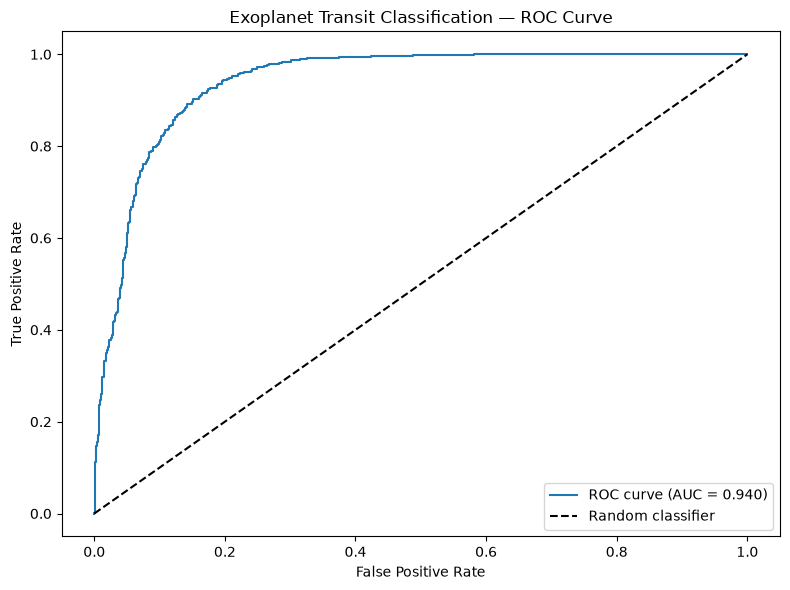

ROC-AUC: 0.940
                  precision    recall  f1-score   support

  False Positive       0.93      0.85      0.89       917
Confirmed Planet       0.78      0.90      0.84       549

        accuracy                           0.87      1466
       macro avg       0.86      0.87      0.86      1466
    weighted avg       0.88      0.87      0.87      1466



In [32]:
from sklearn.metrics import roc_curve, auc, classification_report
import matplotlib.pyplot as plt

y_prob = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Exoplanet Transit Classification — ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.3f}")
print(classification_report(y_test, clf.predict(X_test),
      target_names=['False Positive', 'Confirmed Planet']))

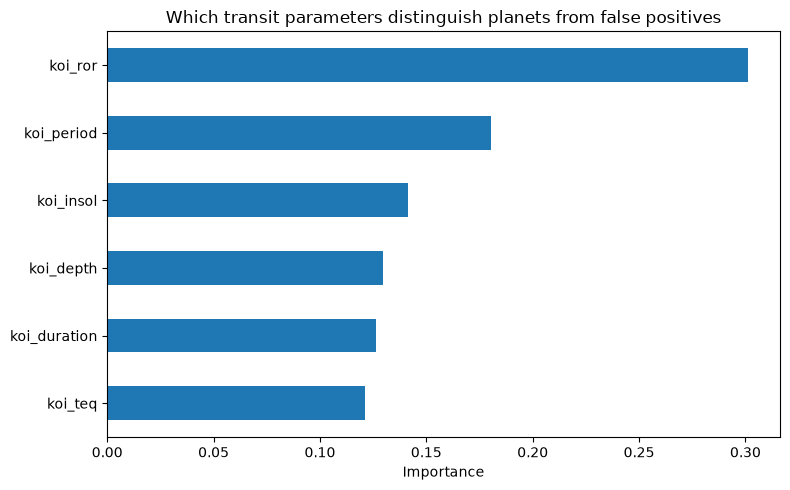

koi_teq         0.121266
koi_duration    0.126176
koi_depth       0.129567
koi_insol       0.141542
koi_period      0.180265
koi_ror         0.301184
dtype: float64


In [33]:
import pandas as pd

importances = pd.Series(clf.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.xlabel('Importance')
plt.title('Which transit parameters distinguish planets from false positives')
plt.tight_layout()
plt.show()

print(importances)